<a href="https://colab.research.google.com/github/dsaqib902-bit/Ai-Lab-Task/blob/main/question1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Input Size  BFS Time  DFS Time
0        1000  0.000281  0.000211
1       40000  0.023771  0.005965
2       80000  0.045606  0.027459
3      200000  0.169809  0.121681
4     1000000  0.748299  1.252086


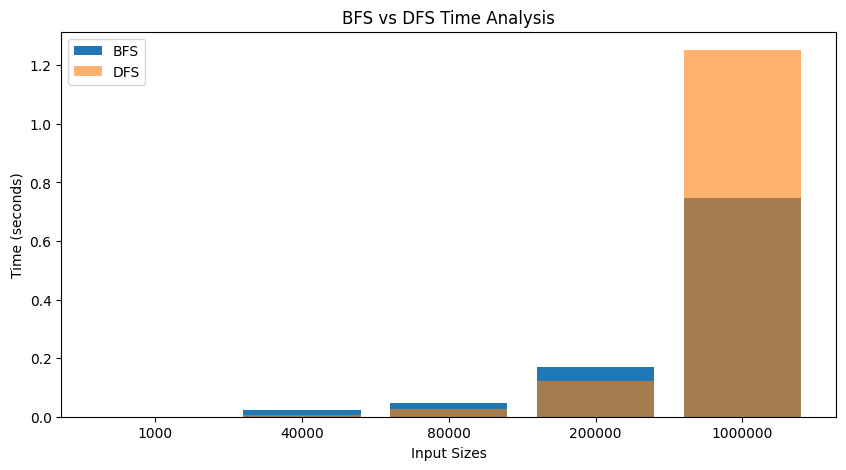

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# Proper BFS for searching in a list treated as tree
def bfs_search_tree(data, goal):
    if not data: return False
    queue = deque([0]) # start with index 0 as root
    visited = set()

    while queue:
        idx = queue.popleft()
        if idx in visited or idx >= len(data):
            continue
        visited.add(idx)

        if data[idx] == goal:
            return True

        # Binary tree: left = 2*i+1, right = 2*i+2
        left, right = 2*idx + 1, 2*idx + 2
        if left < len(data): queue.append(left)
        if right < len(data): queue.append(right)
    return False

# Proper DFS for searching
def dfs_search_tree(data, goal):
    if not data: return False
    stack = [0] # start with index 0 as root
    visited = set()

    while stack:
        idx = stack.pop()
        if idx in visited or idx >= len(data):
            continue
        visited.add(idx)

        if data[idx] == goal:
            return True

        # Binary tree: left = 2*i+1, right = 2*i+2
        left, right = 2*idx + 1, 2*idx + 2
        if right < len(data): stack.append(right) # right first so left is popped first
        if left < len(data): stack.append(left)
    return False

sizes = [1000, 40000, 80000, 200000, 1000000]
bfs_times, dfs_times = [], []

for size in sizes:
    data = random.sample(range(size*10), size)
    goal = data[len(data) - 220] # Task ke mutabiq

    # BFS Time
    start = time.time()
    bfs_search_tree(data, goal)
    bfs_times.append(time.time() - start)

    # DFS Time
    start = time.time()
    dfs_search_tree(data, goal)
    dfs_times.append(time.time() - start)

# DataFrame
df = pd.DataFrame({
    "Input Size": sizes,
    "BFS Time": bfs_times,
    "DFS Time": dfs_times
})
print(df)

# Plot
plt.figure(figsize=(10,5))
plt.bar(range(len(sizes)), bfs_times, label='BFS')
plt.bar(range(len(sizes)), dfs_times, alpha=0.6, label='DFS')
plt.xlabel("Input Sizes")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Time Analysis")
plt.xticks(range(len(sizes)), sizes)
plt.legend()
plt.show()